In [1]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
import random
import cv2

# plt.style.use('ggplot')

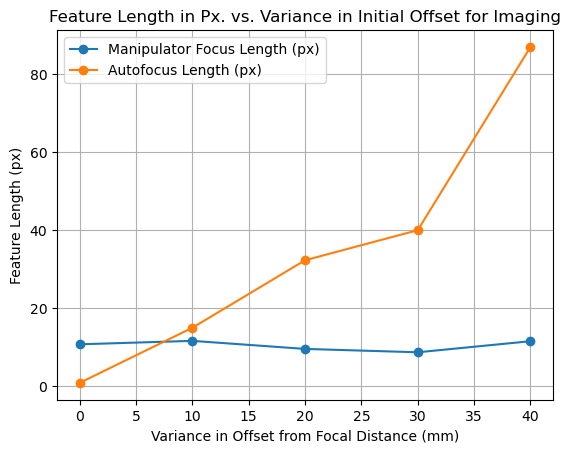

In [ ]:
# Standard Deviation of Defect Scale in Px. vs. Variance in Initial Offset for Imaging
variance = np.array([0, 10, 20, 30, 40])
manipulator_focus_length_px = np.array([10.73820565,
11.62108874,
9.55852312,
8.694630281,
11.53272171])
autofocus_length_px = np.array([0.837291894,
14.97154916,
32.28842733,
40.00000966,
86.98582612])

# Plot both sets of length data against variance
plt.plot(variance, manipulator_focus_length_px, label='Manipulator Autofocus', marker='o')
plt.plot(variance, autofocus_length_px, label='In-lens Autofocus', marker='o')
plt.title('Feature Length in Px. vs. Variance in Initial Offset for Imaging')
plt.xlabel('Variance in Offset from Focal Distance (mm)')
plt.ylabel('Feature Length (px)')
plt.legend()
plt.grid()
plt.savefig('variance_vs_length.pdf')
plt.show()

In [ ]:

def plot_focus_experiment(data_folder):

    data_file = os.path.join(data_folder, "data.json")

    with open(data_file) as f:
        data = json.load(f)

    time = data["time"]
    t0 = time[0]
    # Compute time elapsed based on time
    times = []
    for t in time:
        times.append(t - t0)       

    positions = data["position"]
    p0 = positions[0]
    # Compute distance traveled based on position
    distances = []
    for p in positions:
        distances.append(np.linalg.norm(np.array(p) - np.array(p0))*100)

    # Unpack data
    autofocus_type = data["autofocus_type"]
    metric = data["metric"]

    focus_value = data["focus_value"]
    velocity_times = data["velocity_data"]["time"]
    velocity = data["velocity_data"]["velocity"]
    # Get magnitude of velocity
    velocity_magnitude = []
    for v in velocity:
        speed = np.linalg.norm(np.array(v))
        velocity_magnitude.append(speed)
    for i in range(len(velocity_times)):
        velocity_times[i] = velocity_times[i] - velocity_times[0]

    # Get ratio
    ratio = data["ratio"]

    # Create 1x3 subplots
    fig, axs = plt.subplots(2, 3)
    # Make the figure wider
    fig.set_figwidth(15)
    fig.set_figheight(9)
    # Plot positions against time
    axs[0][0].plot(times, distances)
    axs[0][0].set_xlabel("Time")
    axs[0][0].set_ylabel("Distance (cm)")
    axs[0][0].set_title("Distance vs. Time")
    # Plot focus value against time
    axs[0][1].plot(times, focus_value, c="red")
    axs[0][1].set_xlabel("Time")
    axs[0][1].set_ylabel("Focus Value")
    axs[0][1].set_title("Focus Value vs. Time")
    # Plot focus value against distance
    axs[0][2].plot(distances, focus_value, c="green")
    axs[0][2].set_xlabel("Distance (cm)")
    axs[0][2].set_ylabel("Focus Value")
    axs[0][2].set_title("Focus Value vs. Distance")
    # Plot velocity_magnitude against time
    axs[1][0].plot(velocity_times, velocity_magnitude, c="purple")
    axs[1][0].set_xlabel("Time")
    axs[1][0].set_ylabel("Velocity")
    axs[1][0].set_title("Velocity vs. Time")
    # Plot ratio against time
    # if autofocus_type == "dynamic":
    #     axs[1][1].plot(times, ratio, c="orange")
    #     axs[1][1].set_xlabel("Time")
    #     axs[1][1].set_ylabel("Ratio")
    #     axs[1][1].set_title("Ratio vs. Time")
    # Set title of the entire figure
    fig.suptitle(f"Material: Steel, Autofocus Type: {autofocus_type}, Metric: {metric}, FPS: {round(1/(times[1] - times[0]), 2)}")
    plt.show()

In [ ]:
# Get total time to focus and max focus value from data
def get_total_time_and_max_focus(data_folder):
    data_file = os.path.join(data_folder, "data.json")

    with open(data_file) as f:
        data = json.load(f)

    material = data["material"]
    metric = data["metric"]
    autofocus_type = data["autofocus_type"]
        
    time = data["time"]
    t0 = time[0]
    tf = time[-1]
    total_time = tf - t0
        
    focus_value = data["focus_value"]
    max_focus = focus_value[-1]

    positions = data["position"]
    p0 = positions[0]
    distance_traveled = np.linalg.norm(np.array(positions[-1]) - np.array(p0))*100

    # Load avi file from video.avi
    cap = cv2.VideoCapture(os.path.join(data_folder, "video.avi"))
    # Get final frame
    cap.set(cv2.CAP_PROP_POS_FRAMES, cap.get(cv2.CAP_PROP_FRAME_COUNT)-1)
    ret, frame = cap.read()

    return material, metric, autofocus_type, total_time, max_focus, distance_traveled, frame

In [11]:
ceramic_folder = "./final data/Carbon Fiber"
ceramic_data_folders = [f for f in os.listdir(ceramic_folder) if os.path.isdir(os.path.join(ceramic_folder, f))]
# Load data.json from each folder, assign 'material' key to 'Ceramic'
for folder in ceramic_data_folders:
    data_file = os.path.join(ceramic_folder, folder, "data.json")
    with open(data_file) as f:
        data = json.load(f)
    data["material"] = "Carbon Fiber"
    with open(data_file, 'w') as f:
        json.dump(data, f)


Amount of good data: 246


C:\Users\Colin\AppData\Local\Temp\ipykernel_12496\3700112783.py:135: MatplotlibDeprecationWarning: An artist whose label starts with an underscore was passed to legend(); such artists will no longer be ignored in the future.  To suppress this warning, explicitly filter out such artists, e.g. with `[art for art in artists if not art.get_label().startswith('_')]`.
  axs[0][2].legend(handles=[total_time_, max_focus_])


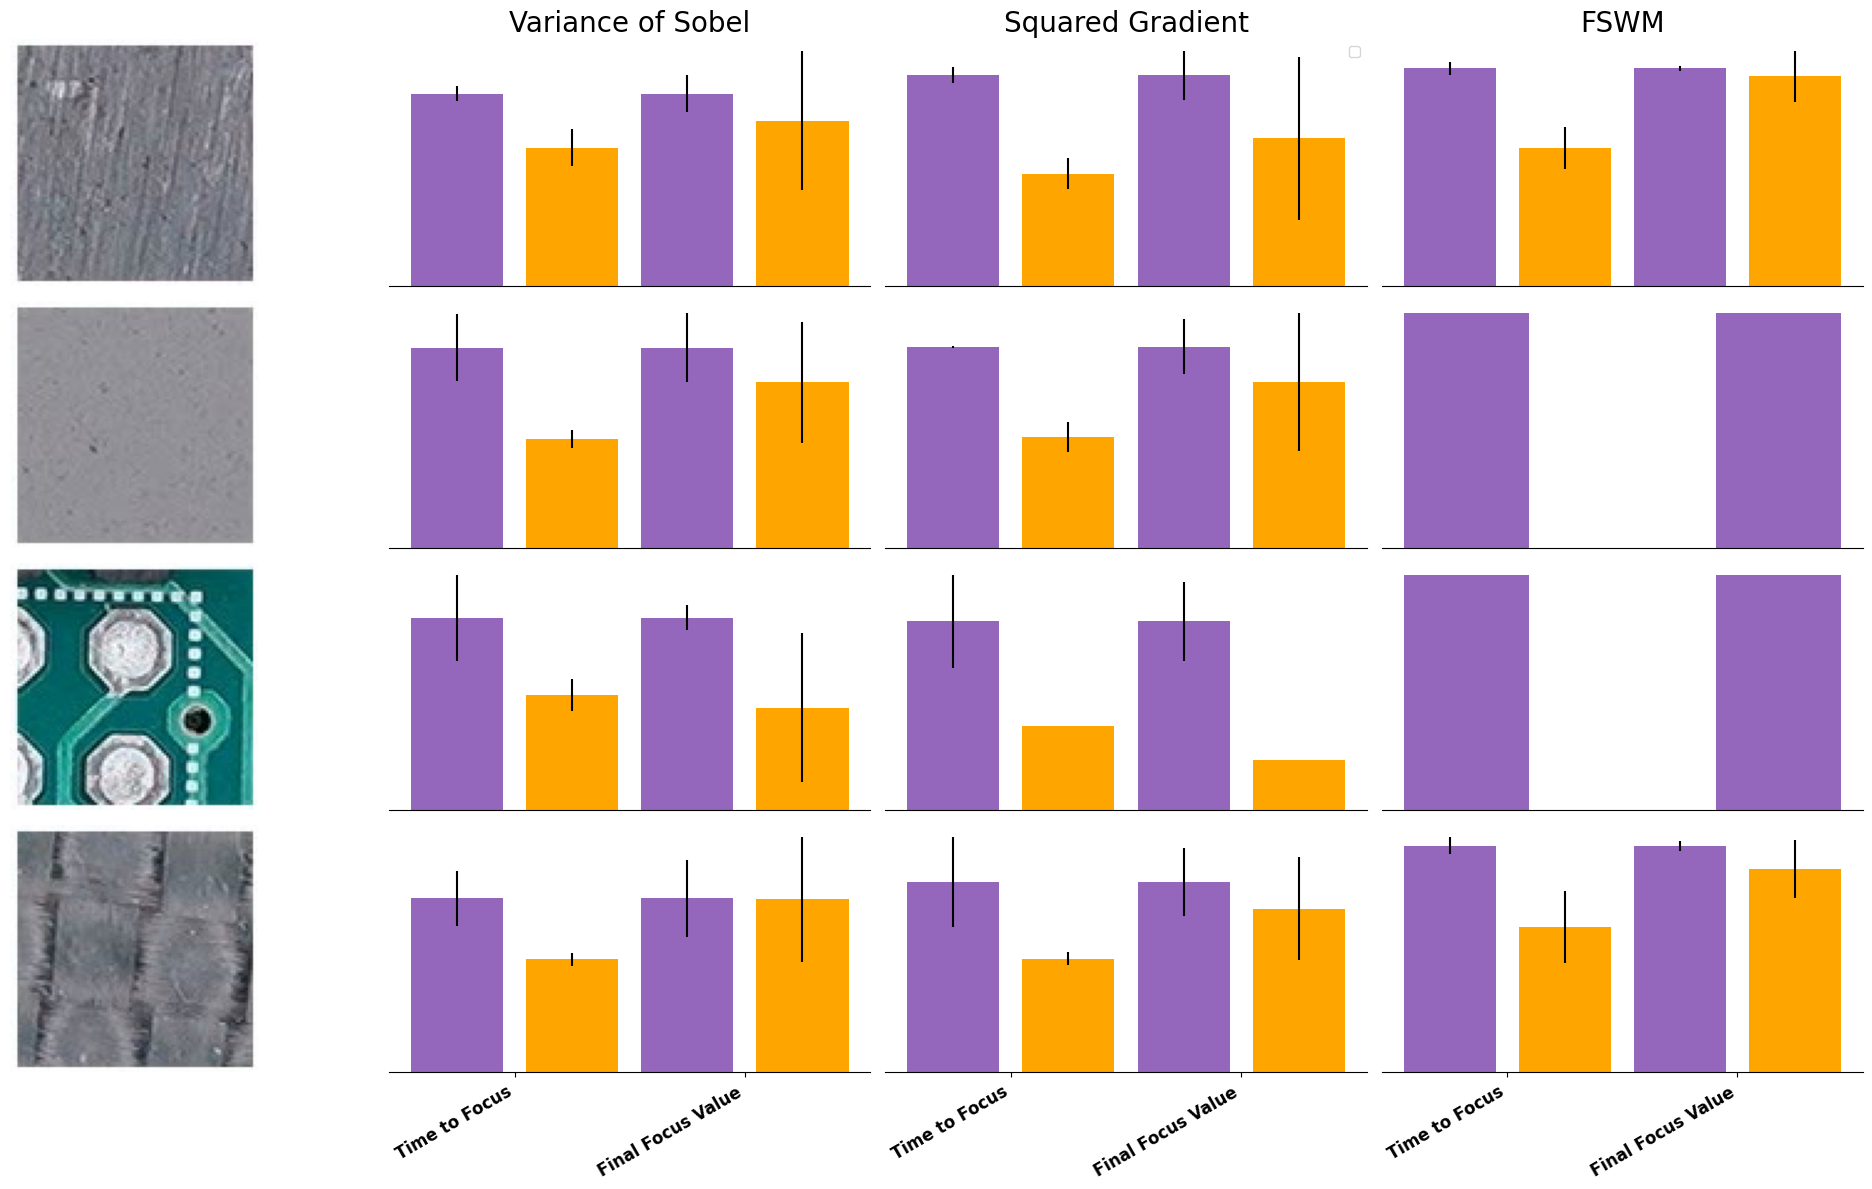

In [ ]:
data_path = "./data/"
# Get all folders in data_path
data_folders = [f for f in os.listdir(data_path) if os.path.isdir(os.path.join(data_path, f))]

materials = ['Steel', 'Ceramic', 'PCB', 'Carbon Fiber']
metrics = ['sobel', 'Squared Gradient', 'FSWM']

data_dict = {}

for material in materials:
    data_dict[material] = {'image': None}
    for metric in metrics:
        data_dict[material][metric] = {}
        for autofocus_type in ['dynamic', 'hillclimb']:
            data_dict[material][metric][autofocus_type] = {}
            data_dict[material][metric][autofocus_type]["total_times"] = []
            data_dict[material][metric][autofocus_type]["max_focus_values"] = []

needs_material_folders = []
good_data_folders = []

for i in range(len(data_folders)):
    # plot_focus_experiment(os.path.join(data_path, data_folders[0]))
    material, metric, autofocus_type, total_time, max_focus, distance_traveled, final_image = get_total_time_and_max_focus(os.path.join(data_path, data_folders[i]))

    # Filter out data that is not useful
    if distance_traveled < 0.5:
        continue
    elif metric is None:
        continue
    elif total_time < 1:
        continue
    elif total_time > 20:
        continue
    elif material == 'sobel' and max_focus > 100000:
        continue
    elif material is None:
        needs_material_folders.append(data_folders[i])
        continue

    good_data_folders.append(data_folders[i])

    if metric == 'Variance of Sobel': metric = 'sobel'
    data_dict[material][metric][autofocus_type]["total_times"].append(total_time)
    data_dict[material][metric][autofocus_type]["max_focus_values"].append(max_focus)
    if metric == 'sobel' and autofocus_type == 'dynamic':
        data_dict[material]['image'] = final_image

print(f"Amount of good data: {len(good_data_folders)}")

# Create a 4x3 subplots
fig, axs = plt.subplots(4, 4, layout='tight')
# Make the figure wider
fig.set_figwidth(20)
fig.set_figheight(12)
# In rows, plot data from each material, in columns plot data from each metric. Plot bar graphs of total time and max focus value for each autofocus type
for i, material in enumerate(materials):
    for j in range(len(metrics) + 1):
        # axs0 = subfigs[i][j].subplots(1,2)

        if j == 0:
            axs[i][j].imshow(data_dict[material]['image'])
            axs[i][j].set_ylabel(f"{material}", fontsize=20)
            axs[i][j].axis('off')
            continue
        elif i == 0:
            if metrics[j-1] == 'sobel':
                axs[i][j].set_title('Variance of Sobel', fontsize=20)
            else:
                axs[i][j].set_title(metrics[j-1], fontsize=20)
        metric = metrics[j-1]
        for k, autofocus_type in enumerate(['hillclimb', 'dynamic']):
            total_times = data_dict[material][metric][autofocus_type]["total_times"]
            max_focus_values = data_dict[material][metric][autofocus_type]["max_focus_values"]

            if len(total_times) == 0:
                total_time_avg = 0
                max_focus_avg = 0
            elif autofocus_type == 'hillclimb':
                total_time_avg = sum(total_times)/len(total_times)
                max_focus_avg = sum(max_focus_values)/len(max_focus_values)
                hillclimb_time_avg = total_time_avg
                hillclimb_max_focus_avg = max_focus_avg
            else:
                total_time_avg = sum(total_times)/len(total_times)
                max_focus_avg = sum(max_focus_values)/len(max_focus_values)
            
            # Normalize data to hillclimb data
            if autofocus_type == 'hillclimb':
                total_time_avg = 1
                max_focus_avg = 1   
            else:
                total_time_avg = total_time_avg/hillclimb_time_avg
                max_focus_avg = max_focus_avg/hillclimb_max_focus_avg
                

            # Add variance to the bar graphs
            if len(total_times) > 1:
                total_times = (np.array(total_times)/hillclimb_time_avg).tolist()
                max_focus_values = (np.array(max_focus_values)/hillclimb_max_focus_avg).tolist()
                total_time_var = np.std(total_times)
                max_focus_var = np.std(max_focus_values)
            else:
                total_time_var = 0
                max_focus_var = 0

            # total_time_ = axs0[0].bar(k, total_time_avg, color="purple", label='Total Time')
            if autofocus_type == 'hillclimb':
                total_time_ = axs[i][j].bar(k+0.5, total_time_avg, color="tab:purple", label='Total Time', yerr=total_time_var)
                max_focus_ = axs[i][j].bar(k+2.5, max_focus_avg, color="tab:purple", label='Max Focus Value', yerr=max_focus_var)
            elif (material == 'PCB' or material == 'Ceramic') and metric == 'FSWM':
                pass
            else:
                total_time_ = axs[i][j].bar(k+0.5, total_time_avg, color="orange", yerr=total_time_var)
                max_focus_ = axs[i][j].bar(k+2.5, max_focus_avg, color="orange", yerr=max_focus_var)
            # turn off x-axis labels
            if i == 3:
                axs[i][j].set_xticks([1, 3])
                axs[i][j].set_xticklabels(labels=['Time to Focus', 'Final Focus Value'], fontsize=12, rotation=30, ha='right', fontweight='bold')
            else:
                axs[i][j].set_xticks([])
            # axs[i][j].set_xticks([1, 3])
            
            # axs[i][j].set(frame_on=False)
            axs[i][j].set(yticks=[])
            # axs[i][j].set(alpha=1)
            # turn off y-axis labels
            # Turn off all borders but the bottom
            axs[i][j].spines['top'].set_visible(False)
            axs[i][j].spines['right'].set_visible(False)
            axs[i][j].spines['left'].set_visible(False)

# Add legend to outer right of the figure and make it bigger
# subfigs[0][2].legend(handles=[total_time_, max_focus_], loc="best", fontsize=20)
axs[0][2].legend(handles=[total_time_, max_focus_])

# Save figure to file
plt.savefig("data_analysis.png")


0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


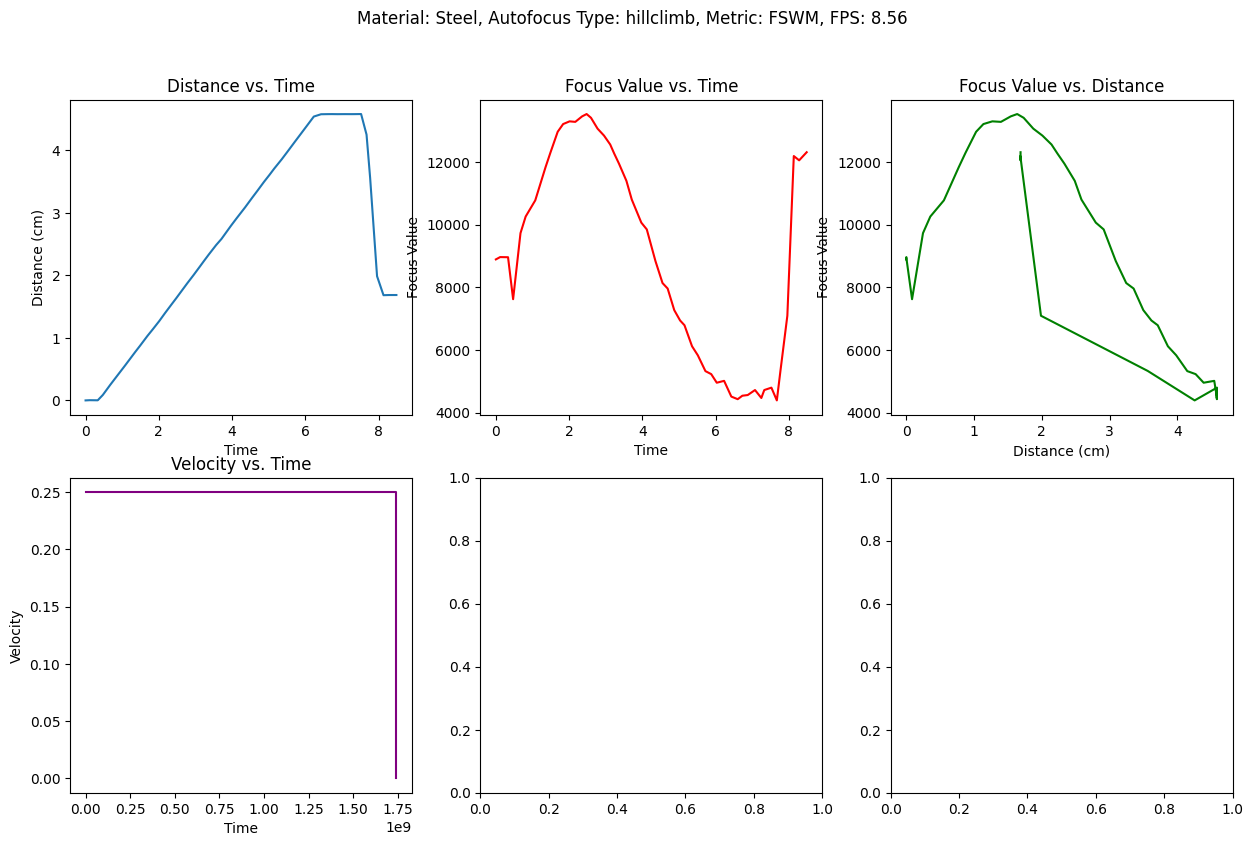

0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


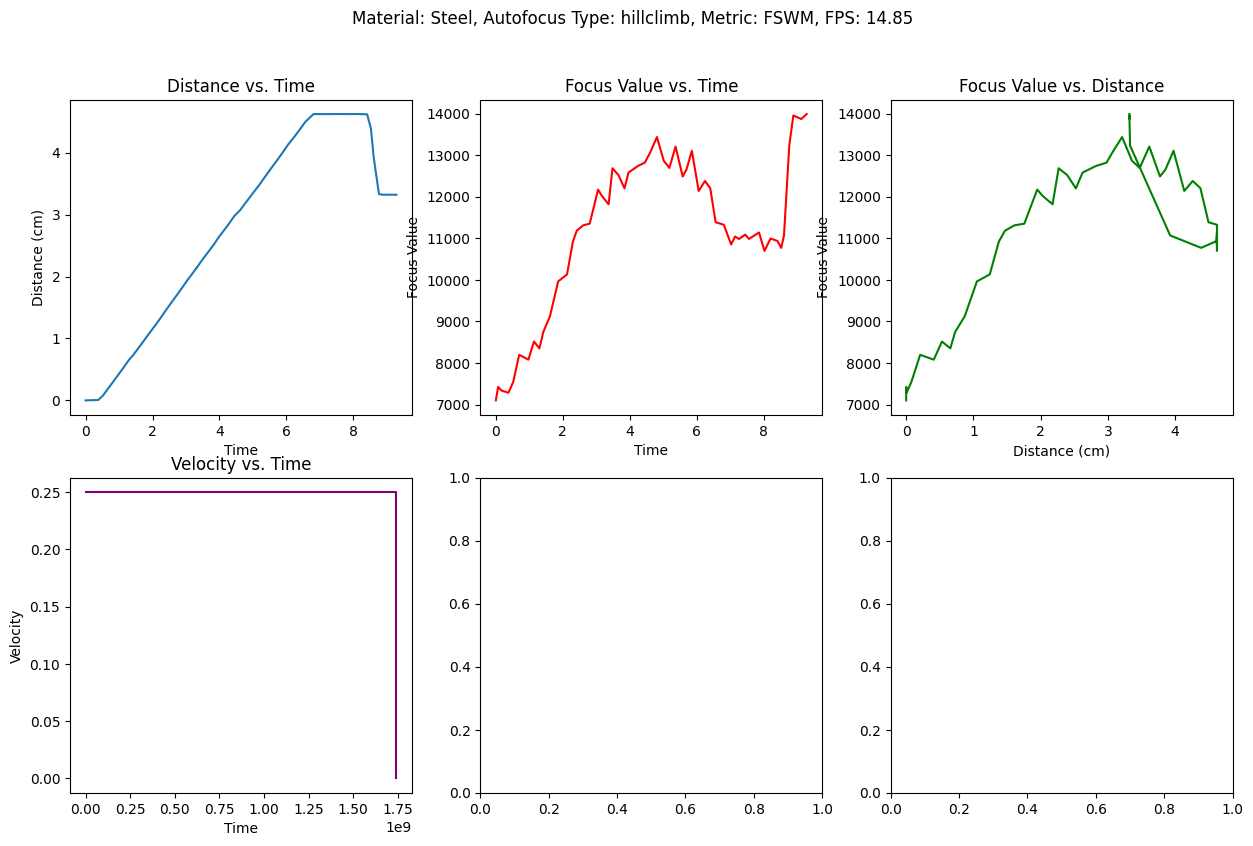

0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


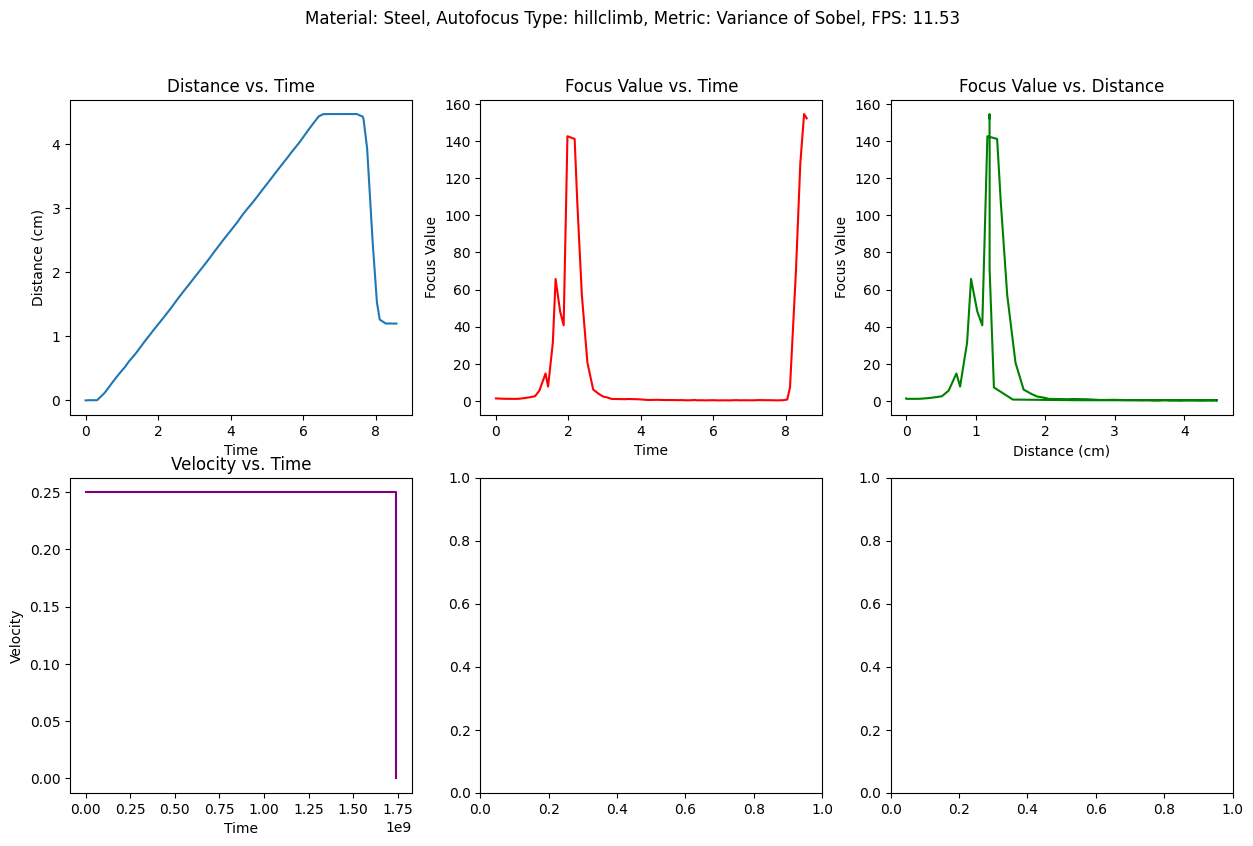

0.0
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


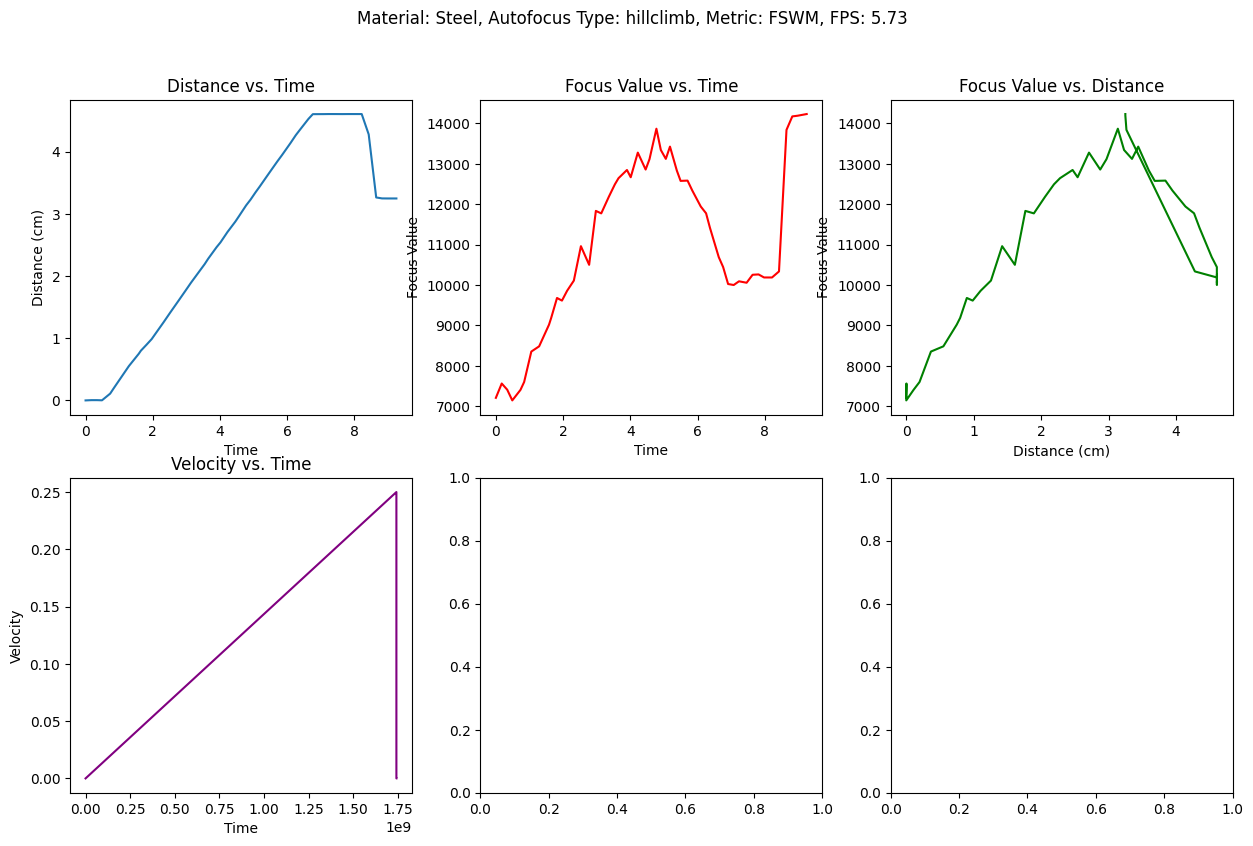

0.25
0.25
0.25
0.25
0.2819432919655271
0.2819432919655271
0.29348417206423244
0.24229627103976942
0.24229627103976942
0.40177664270566676
0.46909894468308855
0.46909894468308855
0.5376557204108511
0.6413131936839723
0.6413131936839723
0.7034282495676709
0.5282242548180802
1.0
1.0
1.0
1.0
1.0
0.7502652094931498
0.7502652094931498
0.2153293371223132
0.2153293371223132
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.25
0.25
0.29997354910294133
0.31087571033166356
0.31087571033166356
0.30325506592298107
0.30325506592298107
0.2677732345671021
0.28392146869549967
0.26268319938308776
0.33657453102982376
0.34224615211476844
0.32608100265487316
0.32608100265487316
0.34896936664044853
0.34896936664044853
0.34896936664044853
0.3615379199928853
0.38536586580267645
0.571179050502877
0.4111377145532825
0.4111377145532825
0.43664568950569377
0.4534386524022614
0.4534386524022614
0.5393587014246024
0.6215592241678957
0.6215592241678957
0.486400112955555
0.742061222548

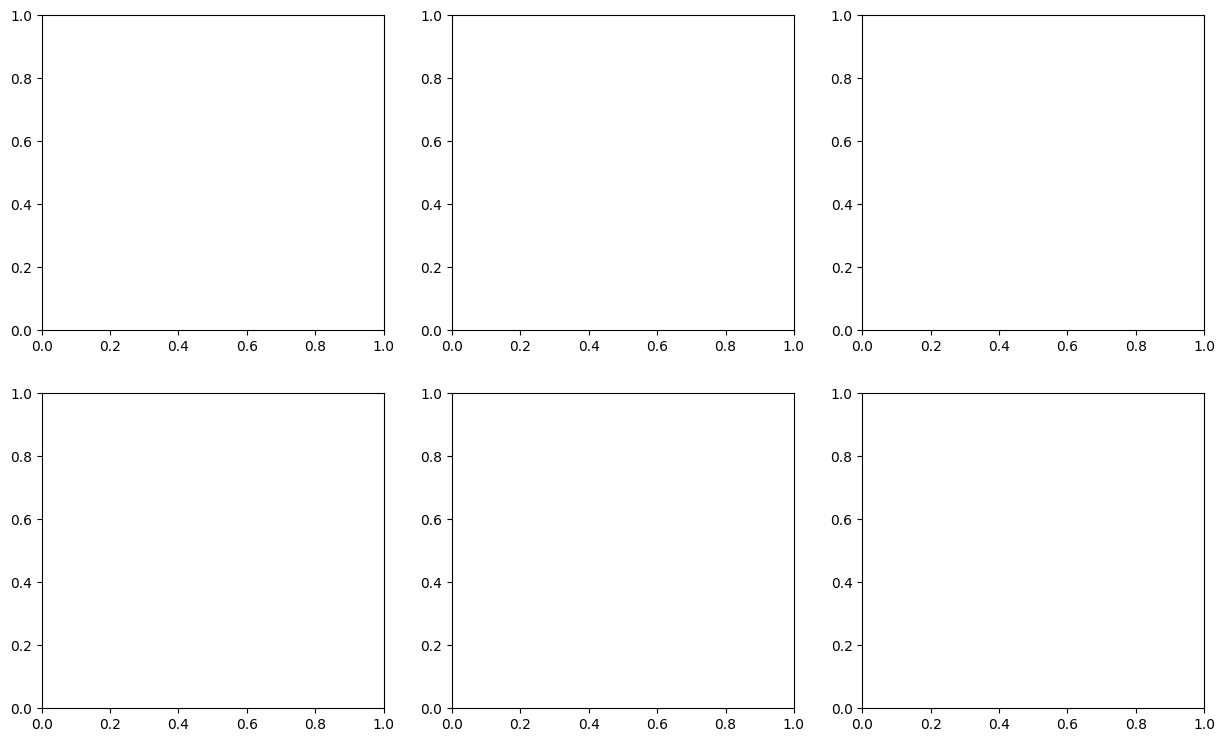

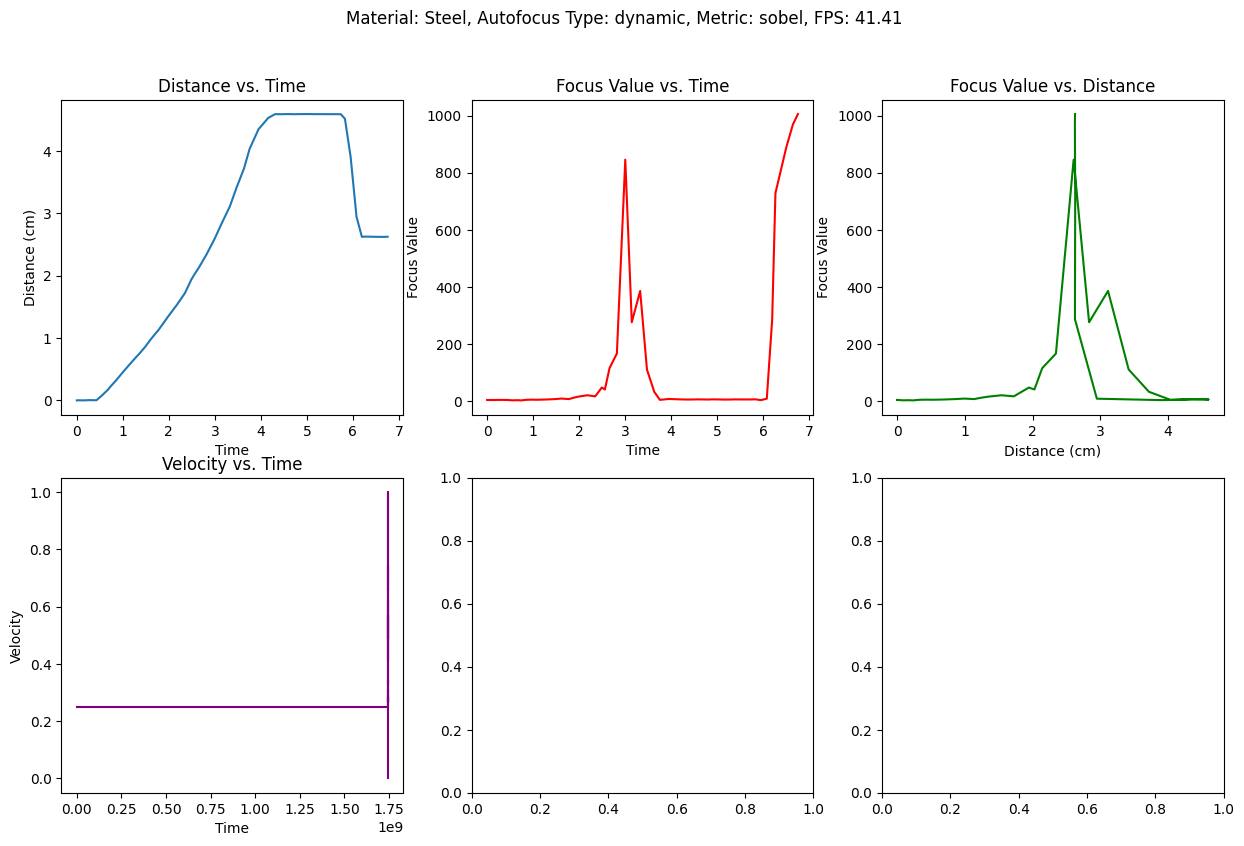

0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


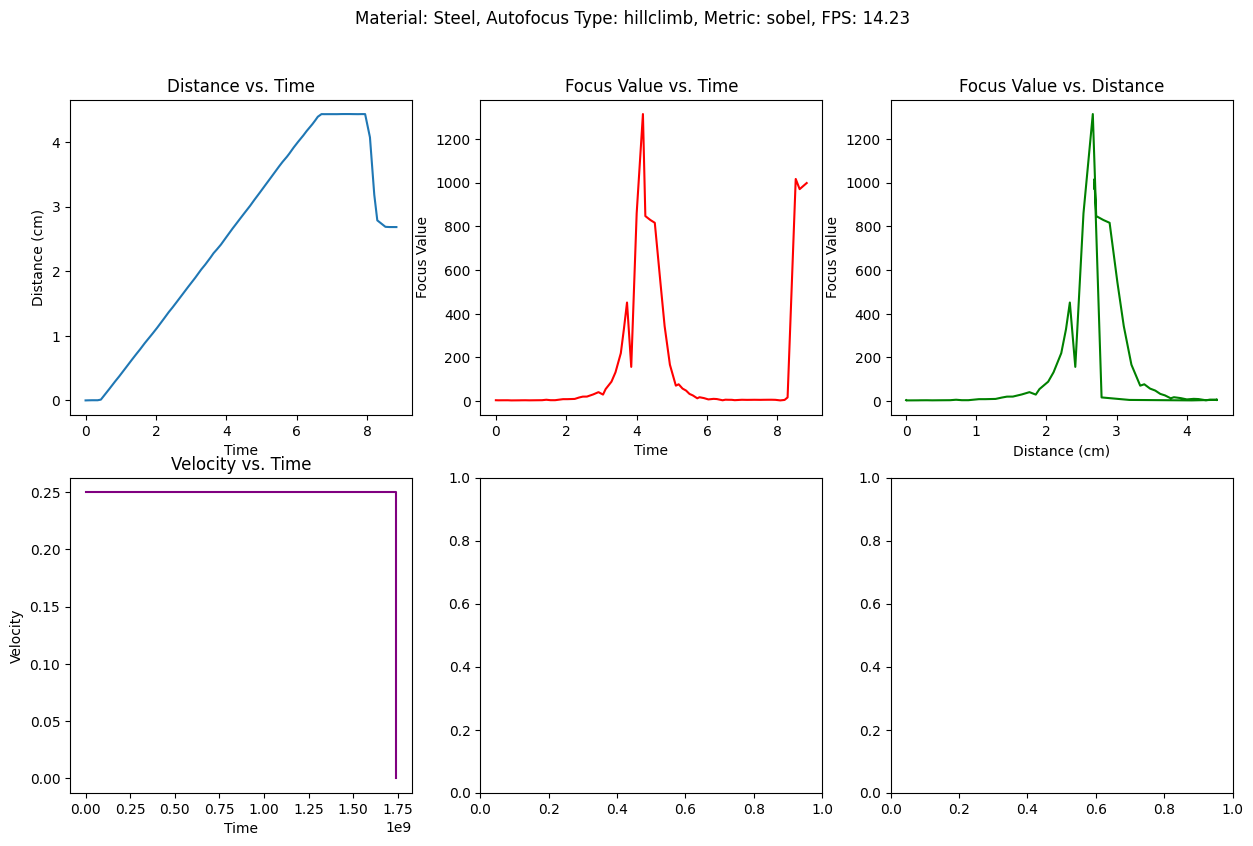

0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


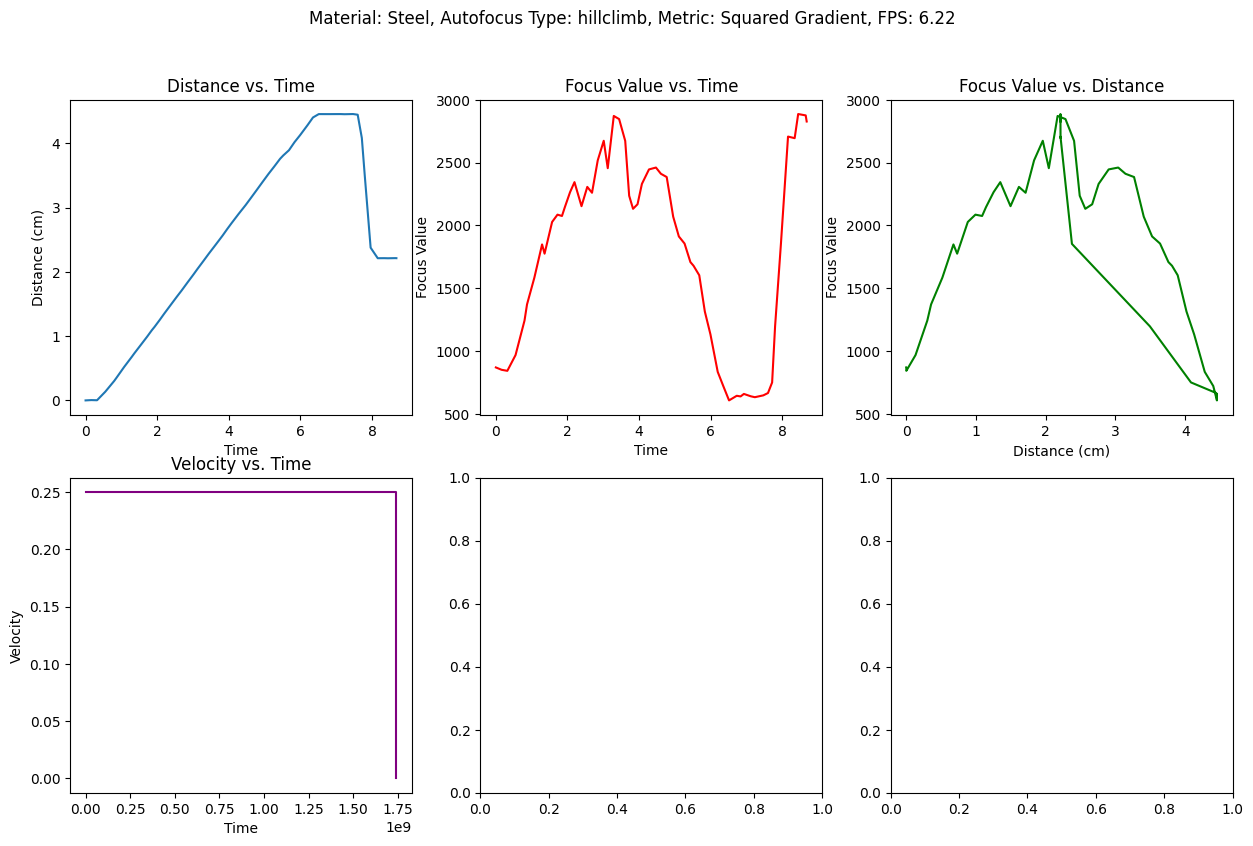

0.25
0.25
0.25
0.29587159387336365
0.3021962924915331
0.2980088404010547
0.2980088404010547
0.3049045944394886
0.29296629107468947
0.29296629107468947
0.3160492114125944
0.26737467092186856
0.26737467092186856
0.2970056493504231
0.3099597399865845
0.3660997030696512
0.3358187733085006
0.3839757298419509
0.39055414649825043
0.34397270253850337
0.3923854527104984
0.36846999553790166
0.3758607432636397
0.3758607432636397
0.41272890403714824
0.5598390372970866
0.5735416345479862
0.4855248632882598
0.5582995995866693
0.3730904719750321
0.756597074482764
0.756597074482764
0.9200652315526026
0.9200652315526026
0.5394599492529224
0.4654649887810747
0.5161272295416901
0.5161272295416901
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


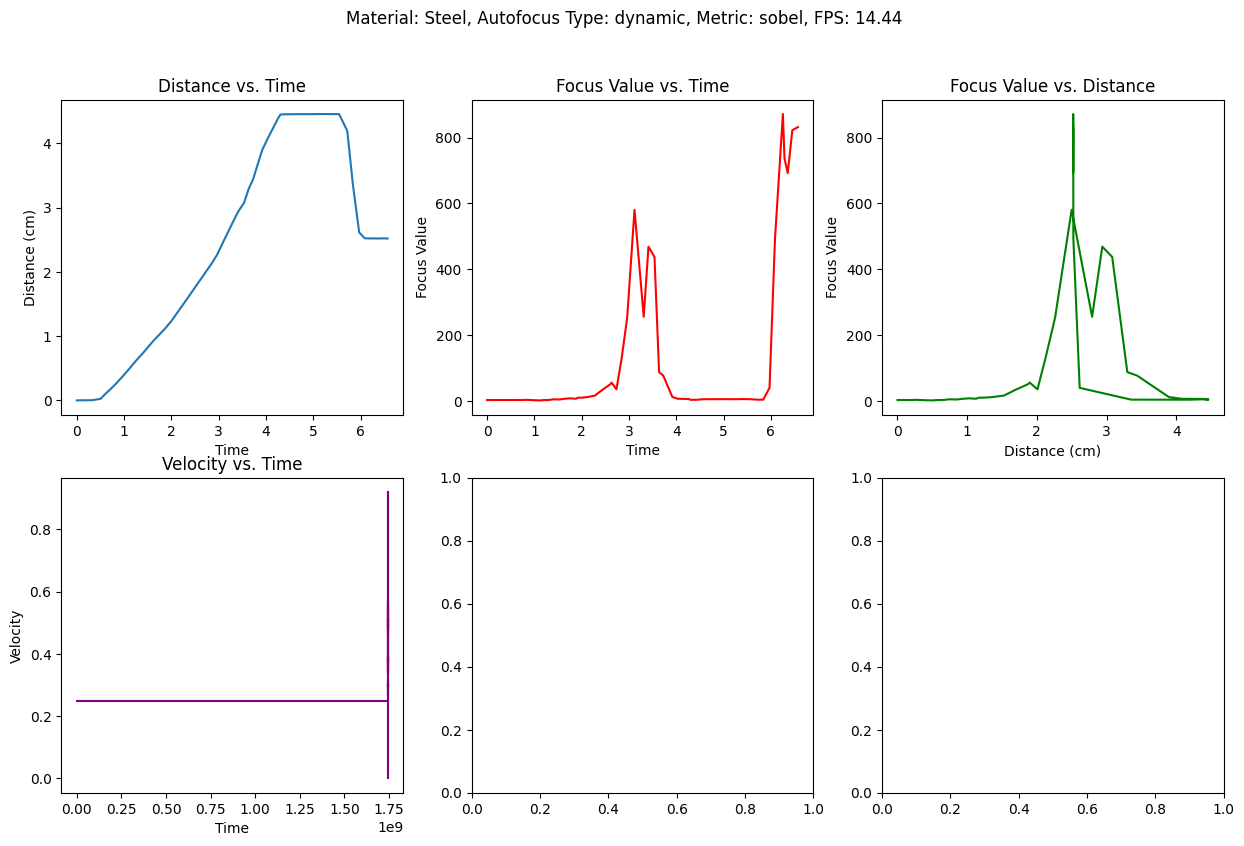

0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


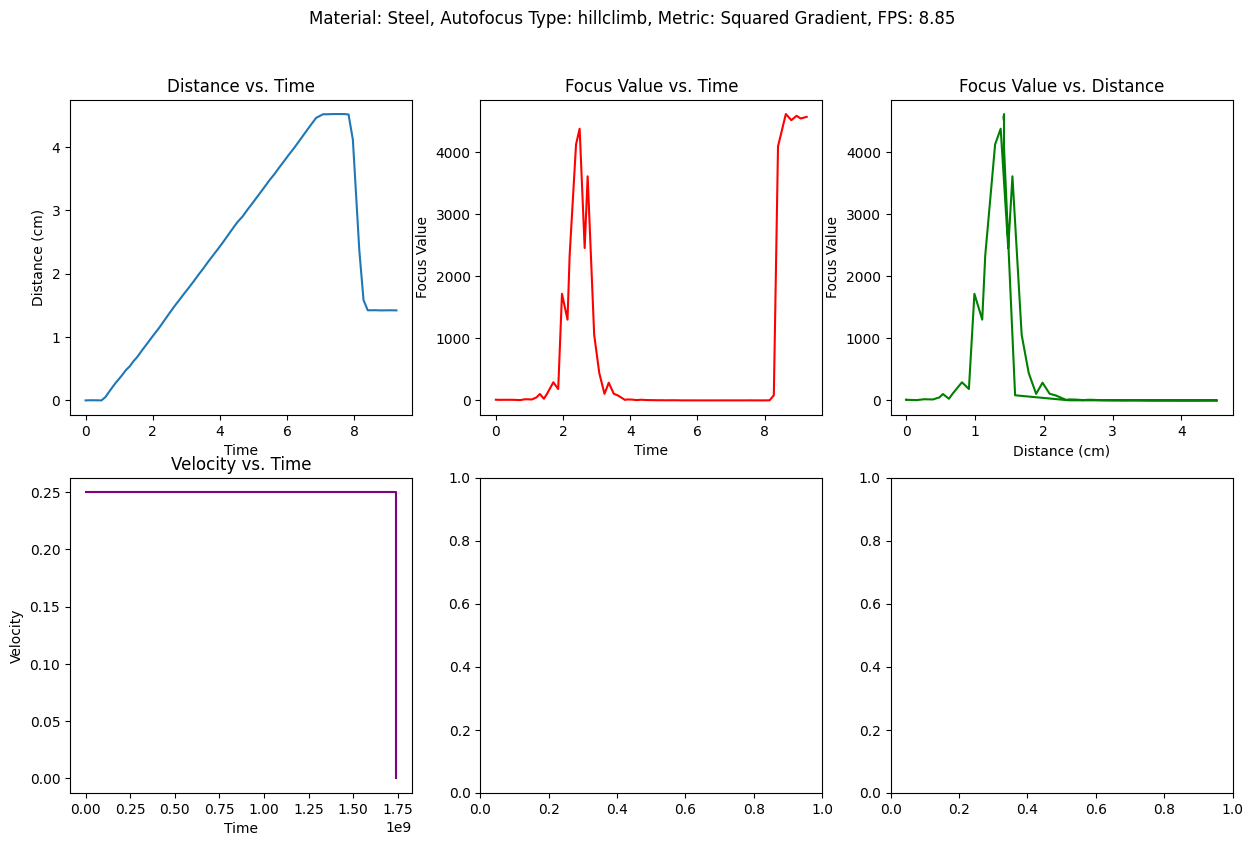

0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


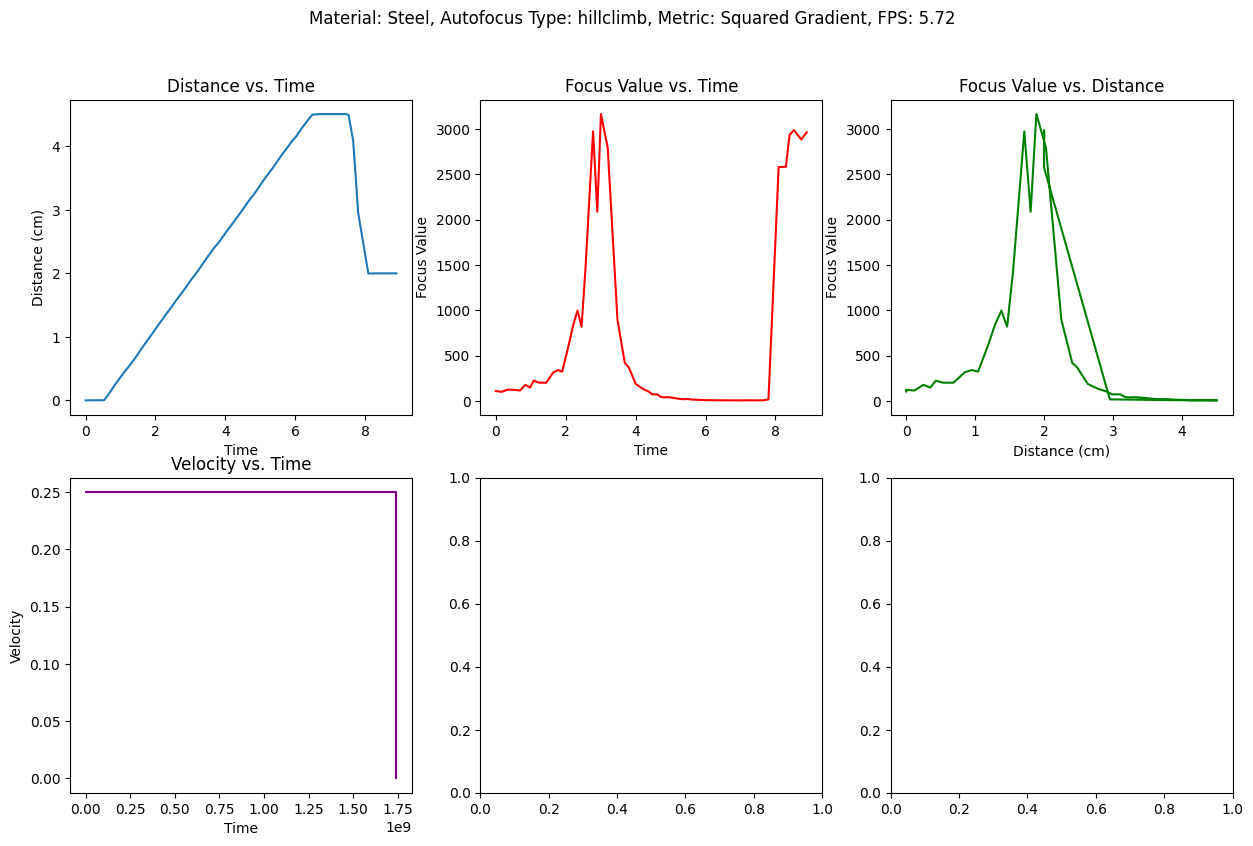

0.25
0.25
0.25
0.5987949651953217
0.3009666086889609
0.3168615373010549
0.3168615373010549
0.3906030031318556
0.3906030031318556
0.8591721148895207
0.9422776522685798
0.9422776522685798
1.0
1.0
1.0
0.27504640643501216
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


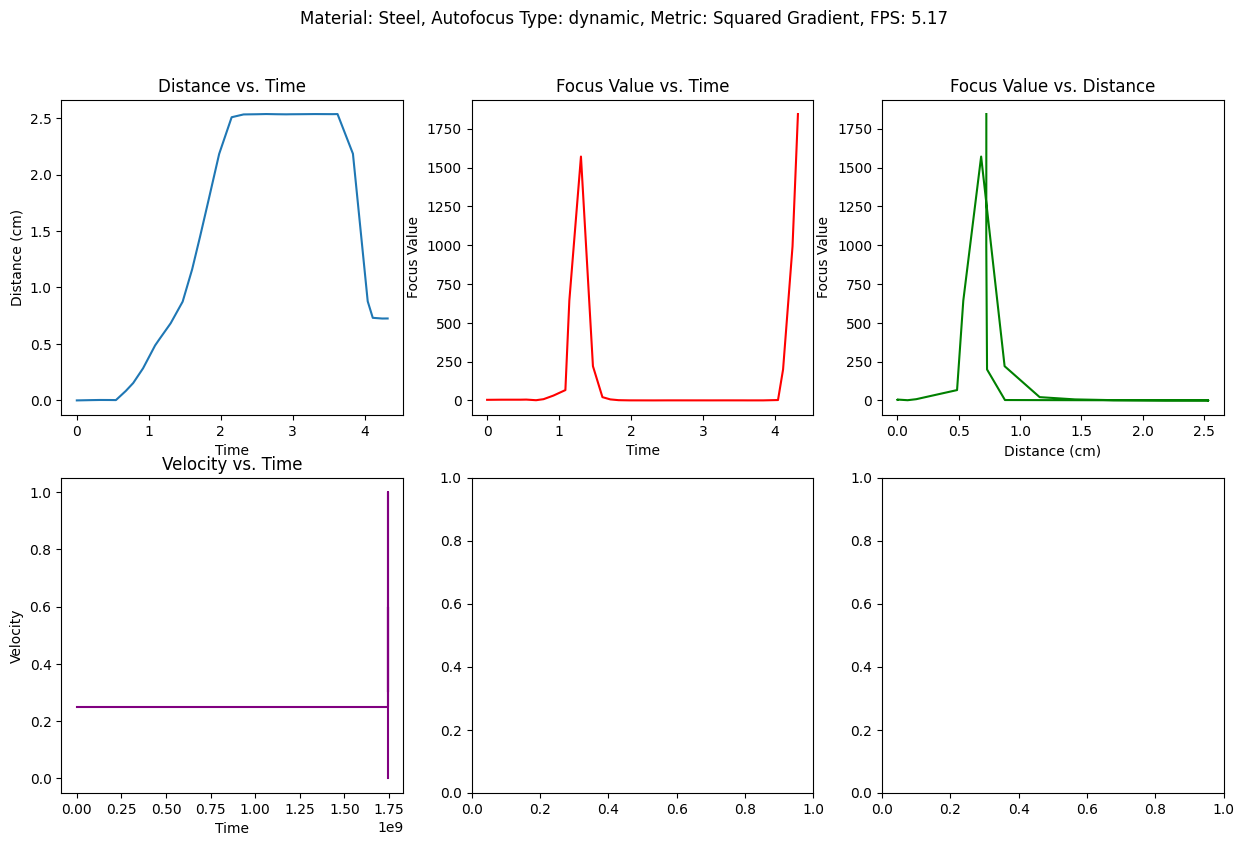

0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


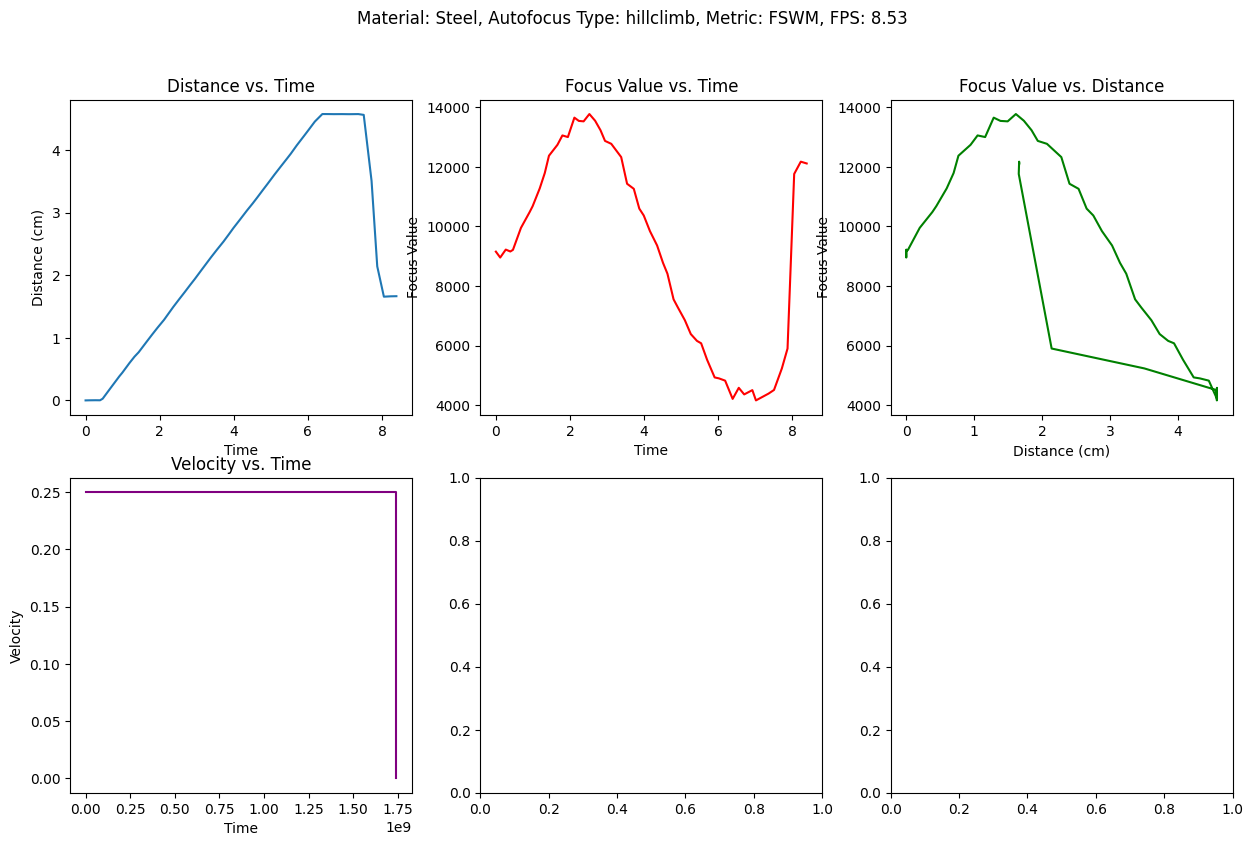

0.0
0.25
0.25
0.2919339256731043
0.2919339256731043
0.29902344077164605
0.29902344077164605
0.2962960810550191
0.2995261288323315
0.30710681863663986
0.37082011774419593
0.37082011774419593
0.5657296373572817
0.40547217650913814
0.40594448919120735
0.3864666253634711
0.4203952775173964
0.4203952775173964
0.45488591249342736
0.5497669942009475
0.5497669942009475
0.5679148632728016
0.7082816768734592
0.7303517424166738
0.5103468093957728
0.5103468093957728
0.8615449886747165
0.8615449886747165
0.6308910793211445
0.2538355943840494
0.2538355943840494
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


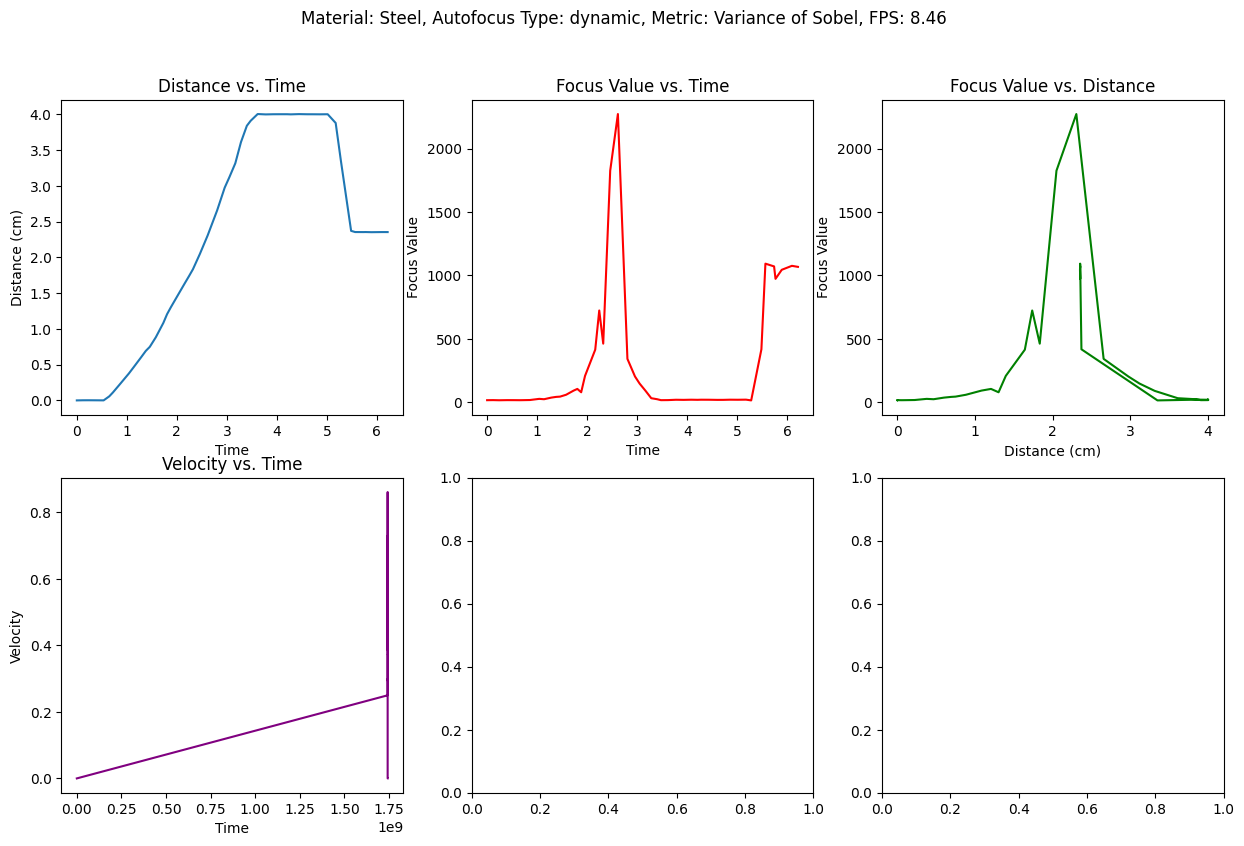

0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


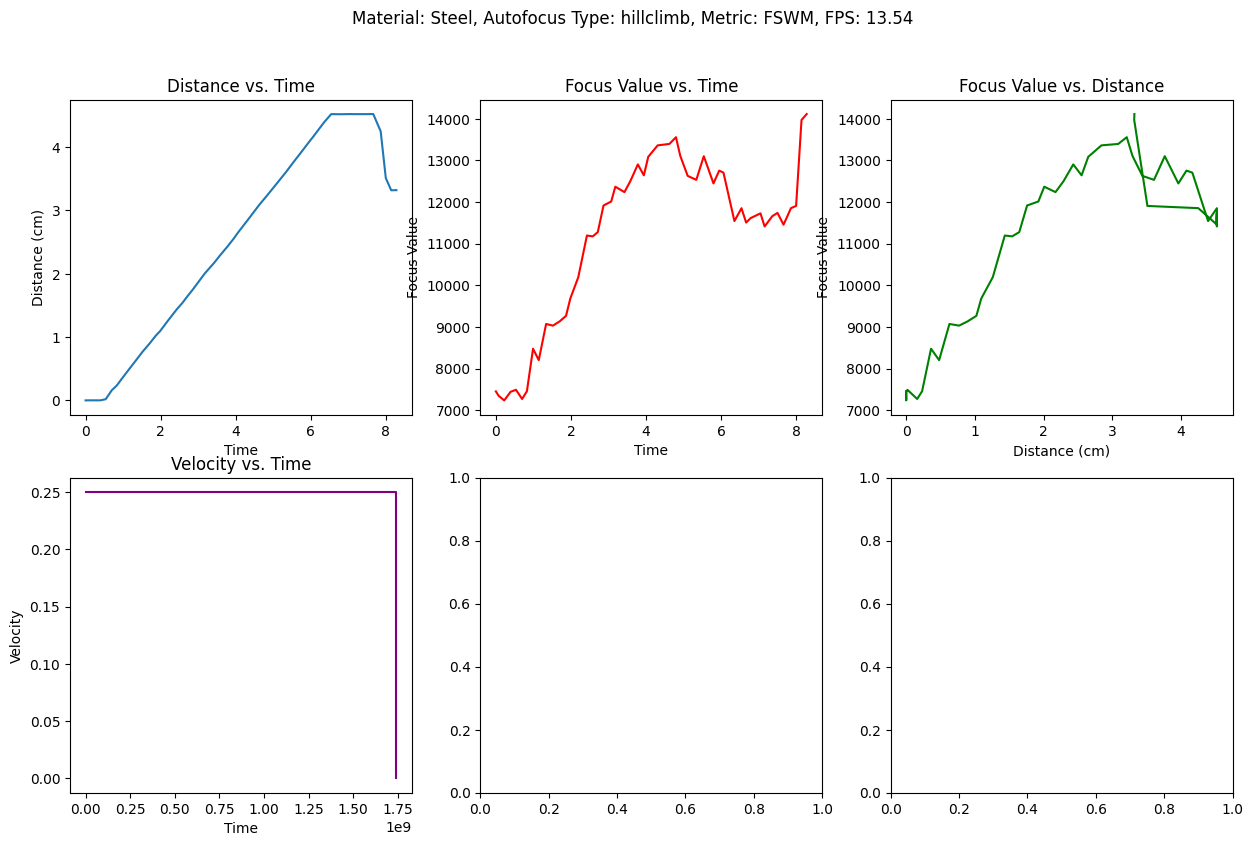

0.25
0.25
0.25
0.25
0.3003313623023312
0.3003313623023312
0.30743563162095067
0.299260465953649
0.299260465953649
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


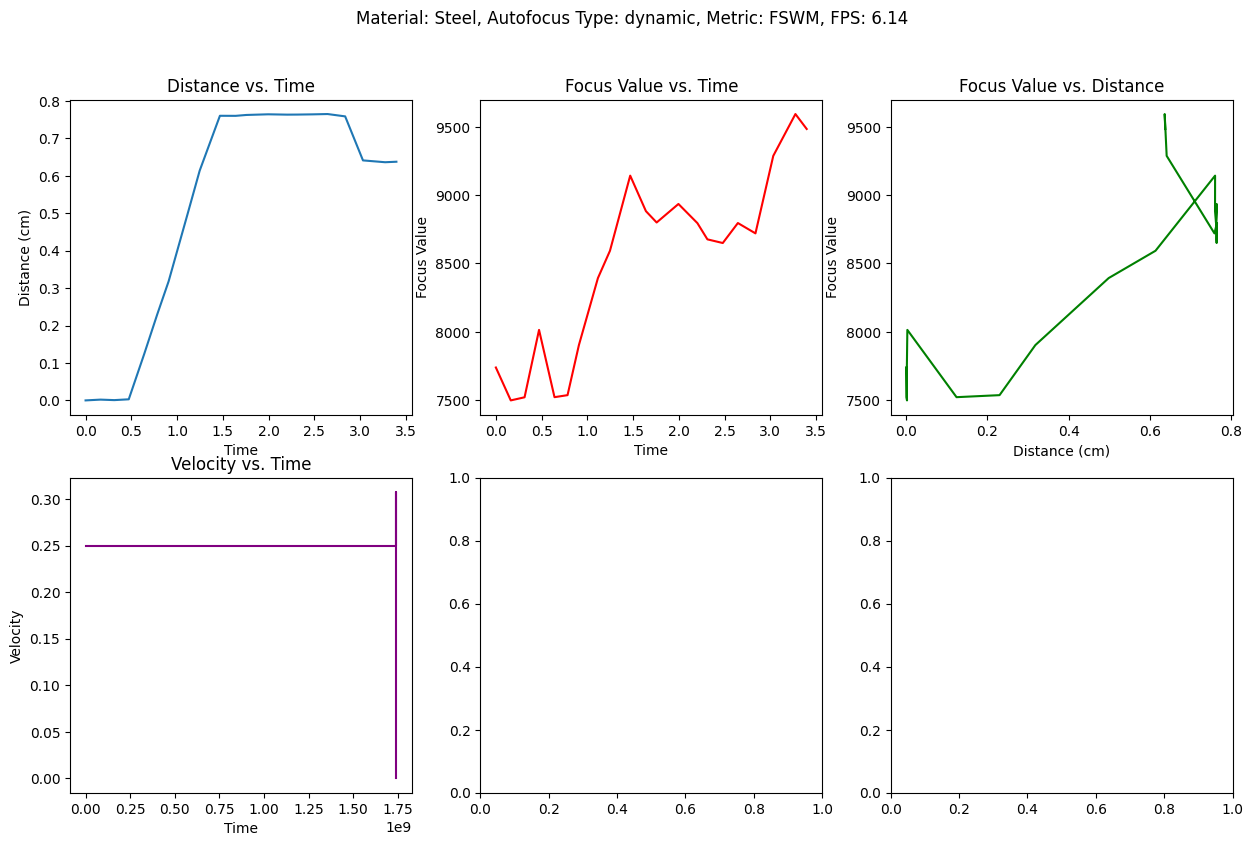

0.0
0.25
0.25
0.25
0.2928492828421964
0.30200988207190693
0.29758377743434716
0.29758377743434716
0.26283162851068503
0.319876573986492
0.3518788476712307
0.35725786813868715
0.35725786813868715
0.3327032966654494
0.3996308617613303
0.42226051603244835
0.42226051603244835
0.4304385629981757
0.4094856335572534
0.4505557002414386
0.45701419876037225
0.4888600465627226
0.4888600465627226
0.8157874663425791
0.39322491198859627
0.5193119776484924
0.47746551869741816
0.7370406963736627
0.7370406963736627
0.4944645868707437
0.4944645868707437
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


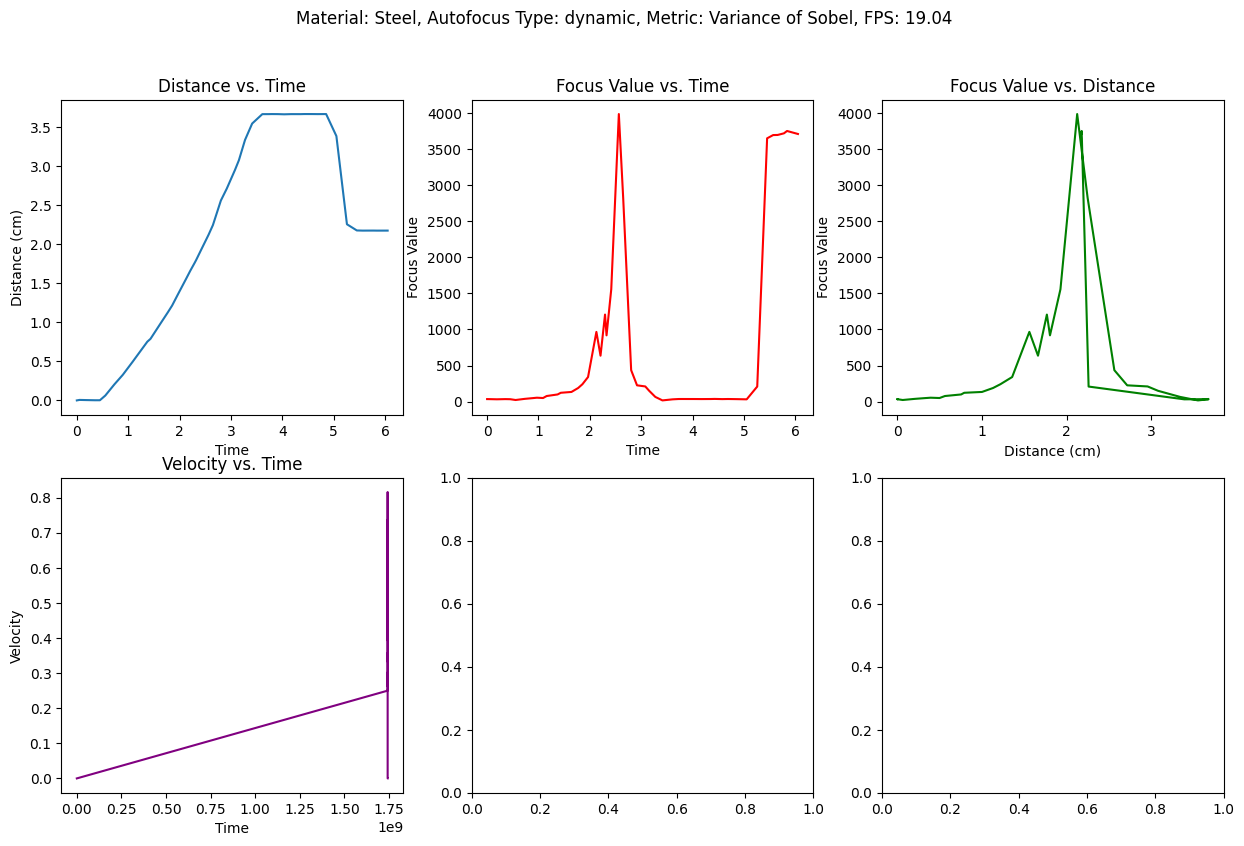

0.25
0.25
0.25
0.3125366055183651
0.3090360094781879
0.3165742272491937
0.2981200387794815
0.29475362782086956
0.29475362782086956
0.2951814842717899
0.2951814842717899
0.3280018854338983
0.318986158736077
0.318986158736077
0.3266504540471447
0.33949048119734965
0.3346591401582364
0.3346591401582364
0.3331382548756044
0.3444197163935048
0.3444197163935048
0.3980937155464893
0.3980937155464893
0.37386699445872407
0.37386699445872407
0.7101111151024164
1.0
1.0
0.5412619404364684
0.42648038690461415
0.28563896957852697
0.28563896957852697
0.28563896957852697
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


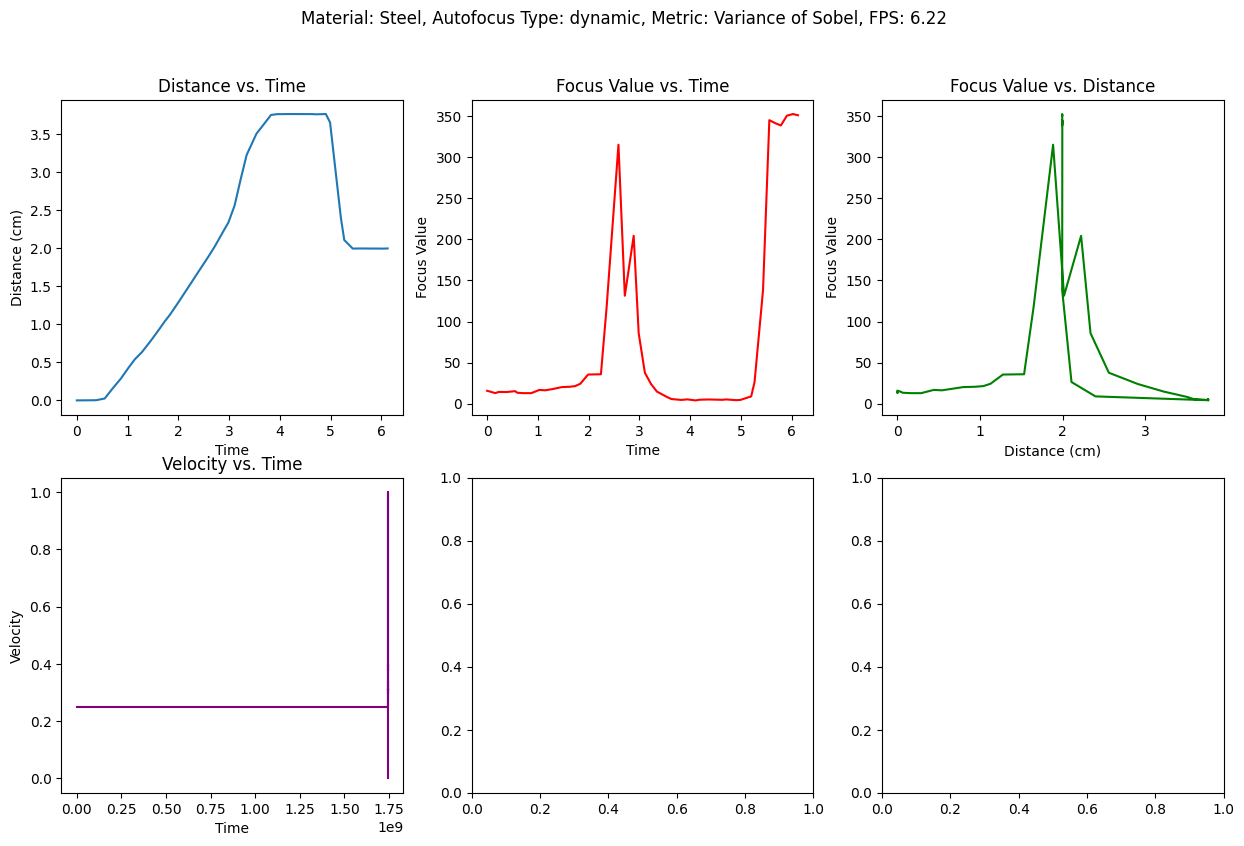

0.25
0.25
0.25
0.25
0.25
0.25
0.3199274782529928
0.31194455622766903
0.5882885897690131
0.5882885897690131
0.5891994634387423
0.2912637379545287
0.2912637379545287
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


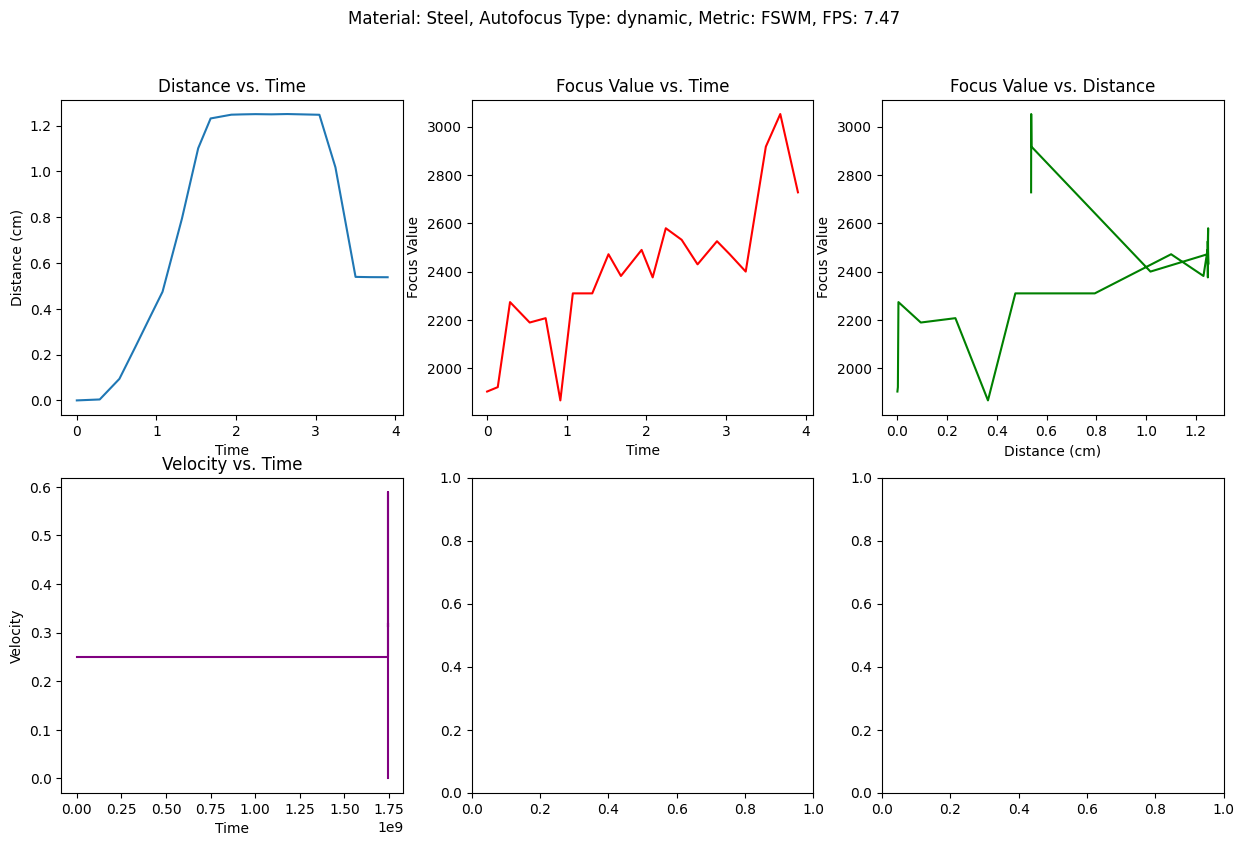

0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.25
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0
0.0


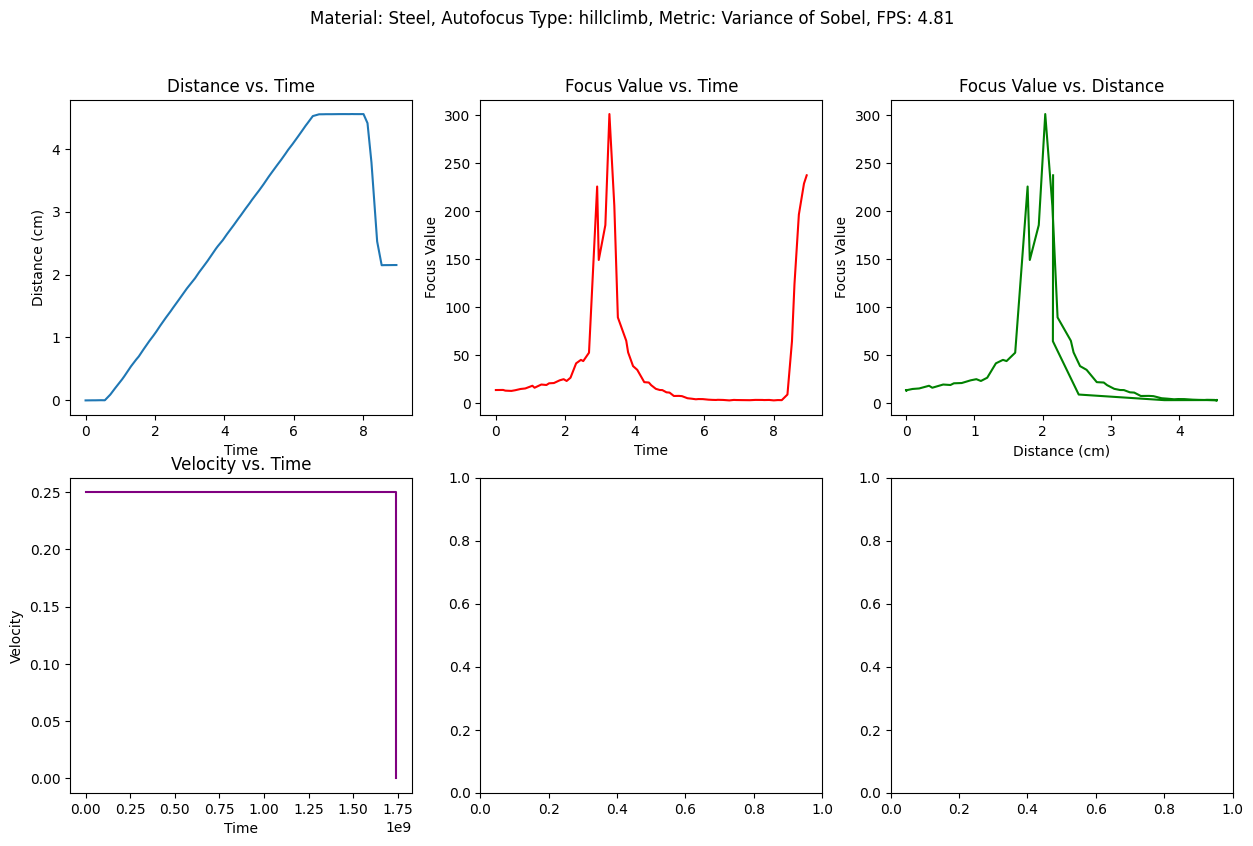

In [13]:
# Plot 10 random sets of data
for i in range(20):
    try:
        plot_focus_experiment(os.path.join(data_path, random.choice(good_data_folders)))
    except:
        continue